# 02 — Document Registry

Inspect the `documents` and `chunks` registry tables that SIRA populates
every time a file is ingested via `/upload-pdf` or `/upload-csv`.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path('../data/stocks.db')
assert DB_PATH.exists(), f'Database not found at {DB_PATH.resolve()}'
con = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH.resolve())

Connected to /home/guimas/Documents/Software/sira/data/stocks.db


## All ingested documents

In [2]:
docs = pd.read_sql('SELECT * FROM documents ORDER BY ingested_at DESC', con)
print(f'{len(docs)} document(s) in registry')
docs

1 document(s) in registry


,id,filename,type,ingested_at,chunks_count
0,1,tmp28q6vh4_.csv,csv,2026-03-31T12:50:04.900398+00:00,0


## Type breakdown

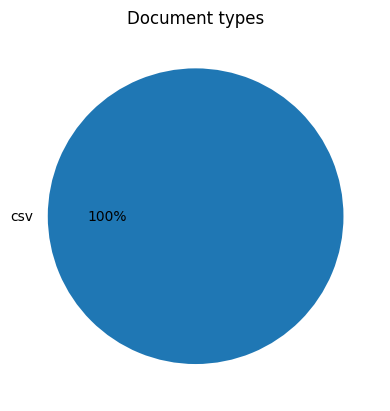

In [3]:
if not docs.empty:
    docs['type'].value_counts().plot.pie(autopct='%1.0f%%', title='Document types')
    plt.ylabel('')
    plt.show()
else:
    print('No documents ingested yet.')

## Chunk counts per document

In [4]:
chunks_per_doc = pd.read_sql(
    """
    SELECT d.filename, d.type, COUNT(c.id) AS chunk_count
    FROM documents d
    LEFT JOIN chunks c ON c.document_id = d.id
    GROUP BY d.id
    ORDER BY chunk_count DESC
    """,
    con,
)
chunks_per_doc

,filename,type,chunk_count
0,tmp28q6vh4_.csv,csv,0


## Bar chart: chunks per document

In [5]:
if not chunks_per_doc.empty and chunks_per_doc['chunk_count'].sum() > 0:
    chunks_per_doc.plot.bar(
        x='filename', y='chunk_count', legend=False,
        title='ChromaDB chunks per document',
    )
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No chunk data to plot.')

No chunk data to plot.


## Page distribution for a specific document

Change `TARGET_FILE` to the filename of a PDF in your registry.

In [6]:
TARGET_FILE = docs['filename'].iloc[0] if not docs.empty else None

if TARGET_FILE:
    page_dist = pd.read_sql(
        """
        SELECT c.page, COUNT(*) AS chunks
        FROM chunks c
        JOIN documents d ON d.id = c.document_id
        WHERE d.filename = ?
        GROUP BY c.page
        ORDER BY c.page
        """,
        con,
        params=(TARGET_FILE,),
    )
    print(f'Page distribution for: {TARGET_FILE}')
    display(page_dist)
    if not page_dist.empty:
        page_dist.plot.bar(x='page', y='chunks', legend=False, title=f'Chunks per page — {TARGET_FILE}')
        plt.tight_layout()
        plt.show()
else:
    print('No documents to inspect.')

Page distribution for: tmp28q6vh4_.csv


,page,chunks


In [7]:
con.close()